# Exploratory Data Analysis (EDA)
**ContextFlow AI** - Enterprise Knowledge Assistant

Analisis yang dilakukan:
- Distribusi panjang teks (instruction & response)
- Distribusi kategori/sumber dataset
- Token frequency analysis
- Statistik deskriptif
- Visualisasi: Histogram, Boxplot, Pie Chart, Scatter Plot, Heatmap

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_from_disk
from app.utils.config import config
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('husl')

print('Imports OK')

d:\bootcamp\final_project_fine_tuning\contextflow_ai_fine_tuning\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Load Preprocessed Data

In [2]:
try:
    train_ds = load_from_disk(os.path.join(config.FORMATTED_DATA_DIR, 'train'))
    val_ds = load_from_disk(os.path.join(config.FORMATTED_DATA_DIR, 'val'))
    df = train_ds.to_pandas()
    print(f'Loaded {len(df)} training samples from disk')
except Exception as e:
    print(f'Formatted data belum tersedia: {e}')
    print('Loading dari raw data...')

    RAW_DIR = r"D:\bootcamp\final_project_fine_tuning\contextflow_ai_fine_tuning\data\raw"

    raw_parts = []
    for source in ['dolly', 'alpaca', 'openassistant', 'coqa']:
        path = os.path.join(RAW_DIR, source)
        ds = load_from_disk(path).to_pandas()

        # coqa punya kolom 'source' (domain), rename biar tidak bentrok
        if 'source' in ds.columns:
            ds = ds.rename(columns={'source': 'domain'})

        ds['source'] = source
        raw_parts.append(ds)
        print(f'  Loaded {len(ds)} samples dari {source}')

    df = pd.concat(raw_parts, ignore_index=True)
    print(f'\nTotal: {len(df)} samples dari semua sumber')
    print(f'Source distribution:\n{df["source"].value_counts()}')

Loaded 8484 training samples from disk


In [3]:
print(df['source'].value_counts())

source
dolly     4708
alpaca    3776
Name: count, dtype: int64


In [4]:
df['instruction_length'] = df['instruction'].str.len()
df['output_length'] = df['output'].str.len()
df['input_length'] = df['input'].str.len()
df['text_length'] = df['text'].str.len()

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset shape: (8484, 9)
Columns: ['instruction', 'input', 'output', 'text', 'source', 'instruction_length', 'output_length', 'input_length', 'text_length']


,instruction,input,output,text,source,instruction_length,output_length,input_length,text_length
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin A...",Virgin Australia commenced services on 31 Augu...,### Instruction:\nWhen did Virgin Australia st...,dolly,42,106,510,704
1,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them...,### Instruction:\nWhy can camels survive for l...,dolly,46,105,0,197
2,"Alice's parents have three daughters: Amy, Jes...",,The name of the third daughter is Alice,### Instruction:\nAlice's parents have three d...,dolly,92,39,0,177


## 2. Statistik Deskriptif

In [5]:
df[['instruction_length', 'output_length', 'input_length', 'text_length']].describe().round(2)

,instruction_length,output_length,input_length,text_length
count,8484.00,8484.00,8484.0,8484.00
mean,63.84,278.90,208.9,597.64
std,62.20,273.24,773.1,824.20
min,10.00,10.00,0.0,74.00
25%,40.00,68.00,0.0,204.00
50%,54.00,181.00,0.0,402.00
75%,72.00,416.00,37.0,708.00
max,2530.00,1494.00,23491.0,24019.00


## 3. Distribusi Sumber Dataset

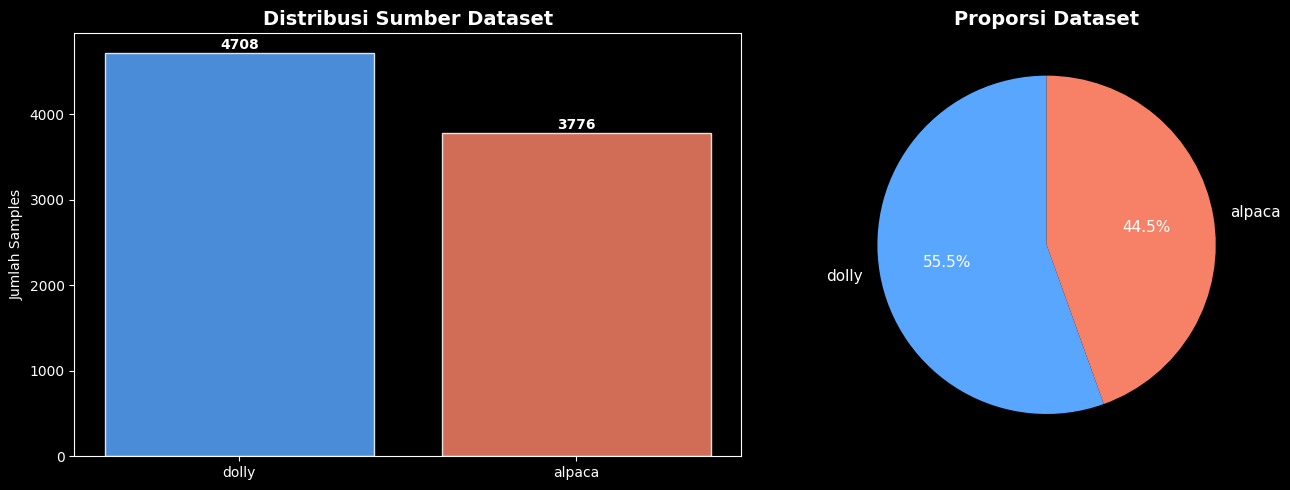

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['source'].value_counts()
colors = ['#58a6ff', '#f78166', '#3fb950', '#bc8cff']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Sumber Dataset', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors,
            textprops={'fontsize': 11}, startangle=90)
axes[1].set_title('Proporsi Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Distribusi Panjang Teks

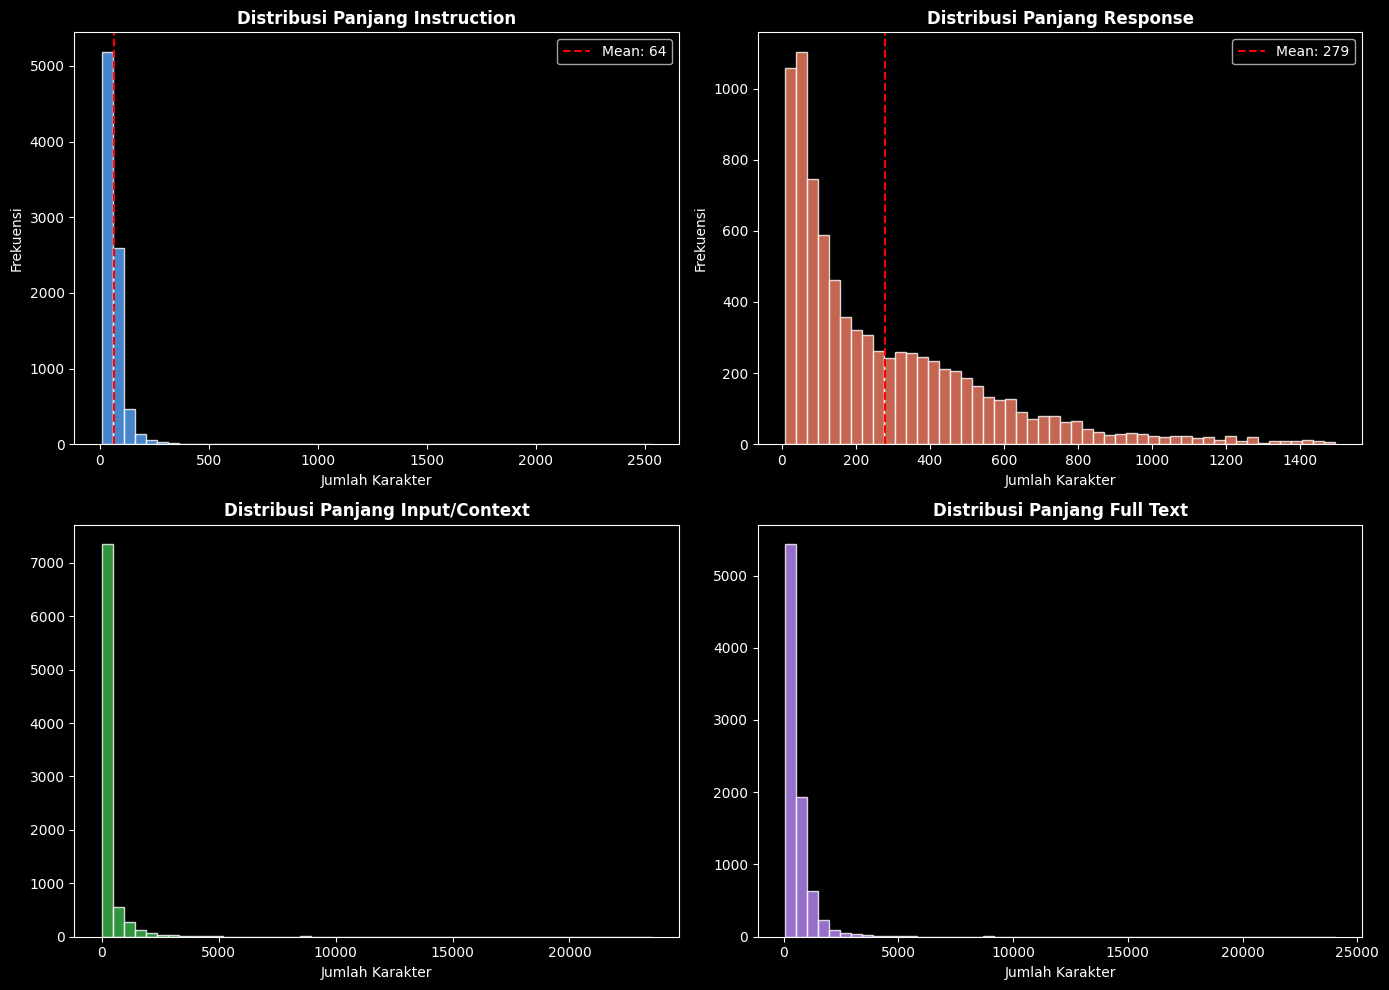

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['instruction_length'], bins=50, color='#58a6ff', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Distribusi Panjang Instruction', fontweight='bold')
axes[0,0].set_xlabel('Jumlah Karakter')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].axvline(df['instruction_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['instruction_length'].mean():.0f}")
axes[0,0].legend()

axes[0,1].hist(df['output_length'], bins=50, color='#f78166', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Distribusi Panjang Response', fontweight='bold')
axes[0,1].set_xlabel('Jumlah Karakter')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].axvline(df['output_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['output_length'].mean():.0f}")
axes[0,1].legend()

axes[1,0].hist(df['input_length'], bins=50, color='#3fb950', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Distribusi Panjang Input/Context', fontweight='bold')
axes[1,0].set_xlabel('Jumlah Karakter')

axes[1,1].hist(df['text_length'], bins=50, color='#bc8cff', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Distribusi Panjang Full Text', fontweight='bold')
axes[1,1].set_xlabel('Jumlah Karakter')

plt.tight_layout()
plt.show()

## 5. Boxplot per Sumber

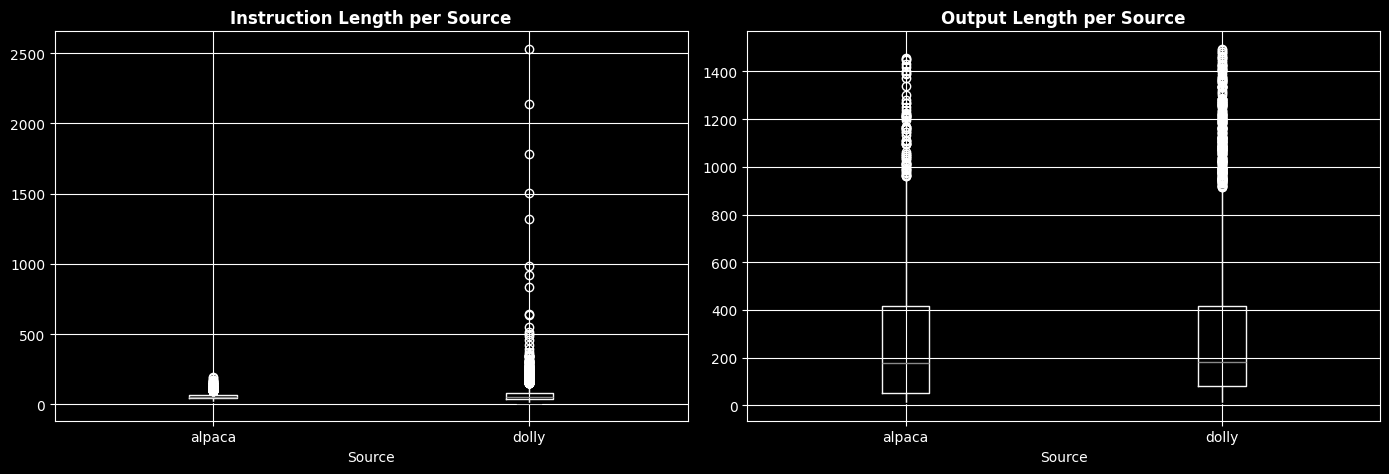

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='instruction_length', by='source', ax=axes[0])
axes[0].set_title('Instruction Length per Source', fontweight='bold')
axes[0].set_xlabel('Source')
plt.suptitle('')

df.boxplot(column='output_length', by='source', ax=axes[1])
axes[1].set_title('Output Length per Source', fontweight='bold')
axes[1].set_xlabel('Source')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 6. Scatter Plot

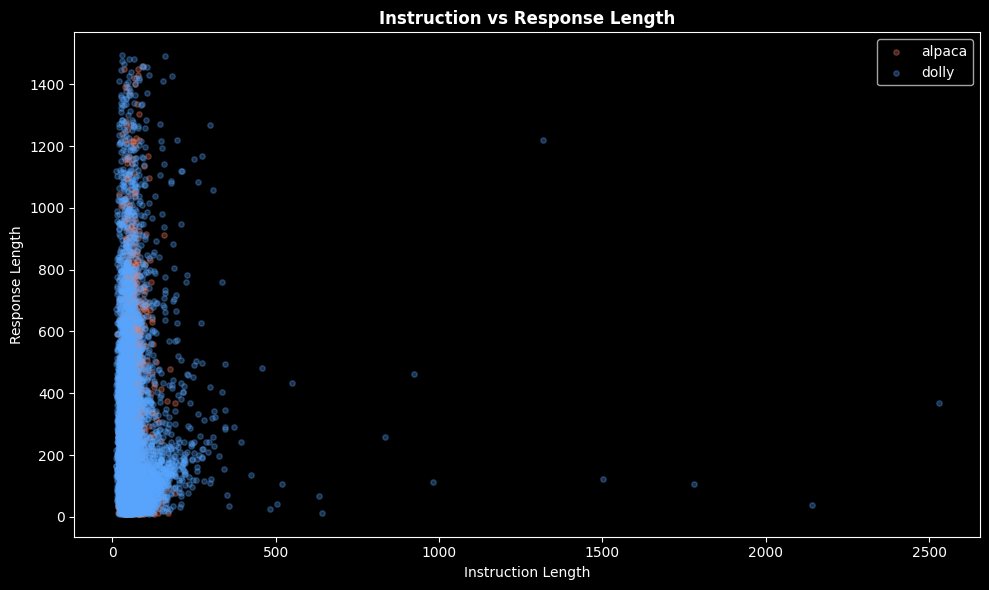

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
color_map = {'dolly':'#58a6ff','alpaca':'#f78166','openassistant':'#3fb950','multidoc2dial':'#bc8cff'}
for src, grp in df.groupby('source'):
    ax.scatter(grp['instruction_length'], grp['output_length'], alpha=0.3, s=15, label=src, color=color_map.get(src,'gray'))
ax.set_xlabel('Instruction Length')
ax.set_ylabel('Response Length')
ax.set_title('Instruction vs Response Length', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

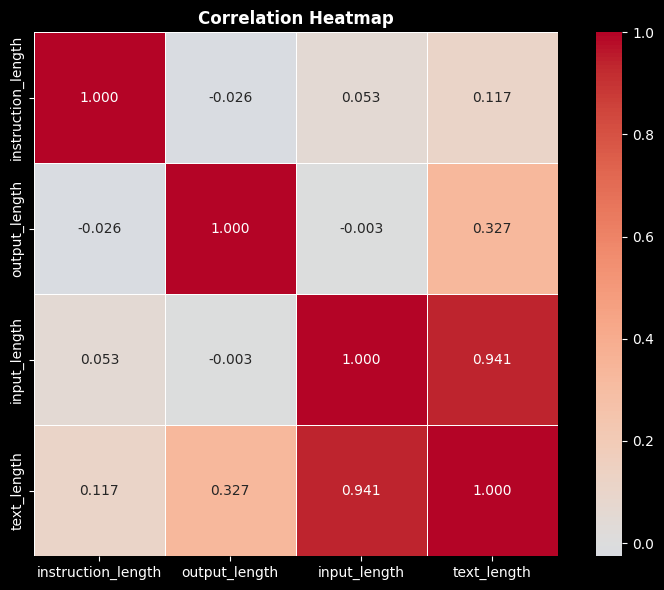

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
numeric_cols = df[['instruction_length', 'output_length', 'input_length', 'text_length']]
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', ax=ax, linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Token Frequency (Top Words)

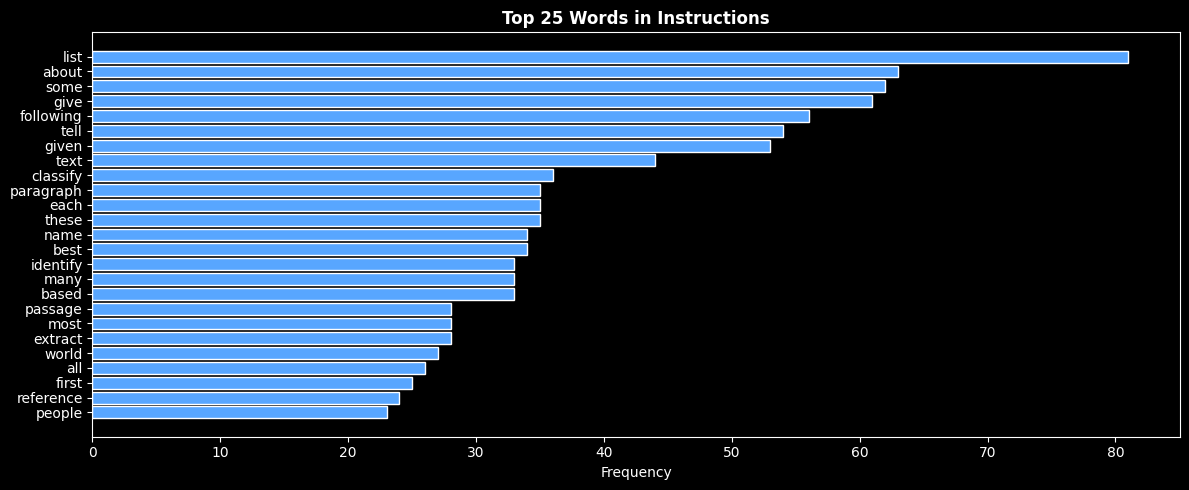

In [11]:
import re

sample_text = ' '.join(df['instruction'].head(1000).tolist())
words = re.findall(r'\w+', sample_text.lower())

stopwords = {'the','a','an','is','are','was','were','to','of','in','for','on','and','or','it','this','that','with','as','by','at','from','be','has','have','had','do','does','did','will','would','can','could','should','not','no','but','if','what','how','when','where','who','which','why','i','you','he','she','we','they','me','my','your','his','its','our','their'}
filtered = [w for w in words if w not in stopwords and len(w) > 2]
word_freq = Counter(filtered).most_common(25)

fig, ax = plt.subplots(figsize=(12, 5))
words_list, counts_list = zip(*word_freq)
ax.barh(range(len(words_list)), counts_list, color='#58a6ff', edgecolor='white')
ax.set_yticks(range(len(words_list)))
ax.set_yticklabels(words_list)
ax.invert_yaxis()
ax.set_title('Top 25 Words in Instructions', fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

## 9. Ringkasan EDA

| Aspek | Temuan |
|-------|--------|
| Total Dataset | ~20,000 samples (setelah sampling & cleaning) |
| Sumber | 4 dataset (Dolly, Alpaca, OpenAssistant, coqa) |
| Distribusi | Cukup merata antar sumber |